# National Electricity Consumption Forecasting — EDF Partnership

**Competition:** Kaggle — CentraleSupélec x EDF | **Result:** 1st place among student teams | **Grade:** 19/20

## Objective
Forecast national electricity consumption (Load), solar production, and wind production 
using real EDF datasets and gradient boosting models.

## Approach
1. **Model selection** — benchmarked multiple models (Linear Regression, Random Forest, 
   XGBoost, LightGBM, CatBoost). Gradient boosting methods proved most effective.
2. **Feature engineering** — main focus of the project. Iteratively built 50+ features 
   (temporal cycles, weather proxies, behavioral indicators). Feature engineering yielded 
   significantly more RMSE improvement than hyperparameter tuning.
3. **Feature selection** — via cross-covariance analysis (multiple methods tested).
4. **Multi-target modeling** — one CatBoost model per target (Load, Solar, Wind).
5. **Final prediction** — `Balance = Load - Solar - Wind`

In [127]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

## 1. Data Loading & Feature Engineering

Temporal encoding uses **sine/cosine cycles** to capture periodicity (time-of-day, month, year).
Weather features are combined into physics-inspired proxies (thermal stress, PV yield, wind density effect).
Behavioral features capture demand patterns (peak hours, weekends, energy crisis of 2022).

In [105]:
def build_features(df):
    """Build temporal, weather and behavioral features."""
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['date'])

    # Temporal cycles
    df['tod_sin'] = np.sin(2 * np.pi * df['tod'] / 48)
    df['tod_cos'] = np.cos(2 * np.pi * df['tod'] / 48)
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['toy_sin'] = np.sin(2 * np.pi * df['toy'])
    df['toy_cos'] = np.cos(2 * np.pi * df['toy'])

    # Weather features
    df['temperature'] = df['temperature'].replace(0, np.nan)
    df['temp_x_nebulosity'] = df['temperature'] * df['nebulosity']
    df['wind_effective'] = df['wind'] * df['wind_by_wind_power_weights']
    df['nebulosity_effective'] = df['nebulosity'] * df['nebulosity_by_solar_power_weights']
    df['thermal_stress'] = df['temperature'] - 0.7 * df['wind']
    df['solar_index'] = (100 - df['nebulosity_by_solar_power_weights']) / 100
    df['wind_density_effect'] = df['wind'] ** 3 * df['wind_by_wind_power_weights']
    df['temperature_squared'] = df['temperature'] ** 2
    df['temperature_inverse'] = 1 / df['temperature']
    df['wind_squared'] = df['wind'] ** 2

    # Behavioral features
    df['is_summer'] = df['month'].isin([6, 7, 8]).astype(int)
    df['is_winter'] = df['month'].isin([12, 1, 2]).astype(int)
    df['is_weekend'] = (df['day_type_week'] == 1).astype(int)
    df['is_day_peak_hour'] = df['tod'].between(32, 42).astype(int)
    df['is_solar_possible'] = df['tod'].between(14, 30).astype(int)
    df['is_night'] = ((df['tod'] <= 11) | (df['tod'] >= 42)).astype(int)
    df['is_friday_evening'] = ((df['tod'] >= 36) & (df['day_type_week'] == 5)).astype(int)
    df['is_energy_crisis_2022'] = (df['datetime'] >= pd.to_datetime("2022-02-01").tz_localize("UTC")).astype(int)
    df['temp_hourly_variation_proxy'] = np.abs(df['tod_sin'] * (df['temperature'] - 273.15))

    # Advanced physics proxies
    df['pv_yield_proxy'] = df['solar_index'] * (1 - 0.004 * (df['temperature'] - 25))
    df['solar_variability_proxy'] = df['solar_index'] * df['tod_cos']
    df['temp_wind_interaction'] = df['temperature'] * df['wind']
    df['sun_saturation_proxy'] = df['is_solar_possible'] * df['solar_index'] * df['tod_sin']
    df['heating_demand_proxy'] = np.maximum(18 - df['temperature'], 0)
    df['cooling_demand_proxy'] = np.maximum(df['temperature'] - 22, 0)
    df['network_stress_proxy'] = df['temperature'] * df['is_day_peak_hour'] * df['is_summer']
    df['wind_nebulosity_ratio'] = df['wind'] / (df['nebulosity'] + 1)
    df['temperature_anomaly'] = df['temperature'] - df.groupby('month')['temperature'].transform('mean')

    return df

In [106]:
df = pd.read_csv("train.csv")
df = build_features(df)
df = df.drop(columns=["Date", "date", "Id"])

In [107]:
# === Preparing features and targets ===
X = df.drop(columns=["Load", "Solar_power", "Wind_power", "Electricity_balance_not_controllable"])
Y = df[["Load", "Solar_power", "Wind_power", "Electricity_balance_not_controllable"]]
scaler = StandardScaler()
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.10, shuffle=False)
X_train = X_train.drop(columns=["datetime"], errors="ignore")
X_test = X_test.drop(columns=["datetime"], errors="ignore")


y_train_load = Y_train["Load"]
y_train_solar = Y_train["Solar_power"]
y_train_wind = Y_train["Wind_power"]

y_test_load = Y_test["Load"]
y_test_solar = Y_test["Solar_power"]
y_test_wind = Y_test["Wind_power"]

X1 = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
Y1 = pd.DataFrame(scaler.fit_transform(Y_train), columns=Y_train.columns)

## 2. Feature Selection via Cross-Covariance

**Step 1 — Covariance matrix** between features to identify redundancy (multicollinearity).

**Step 2 — Cross-covariance** between features and targets to select the most predictive ones.
Only features with |cross-covariance| > 0.15 are kept per target.

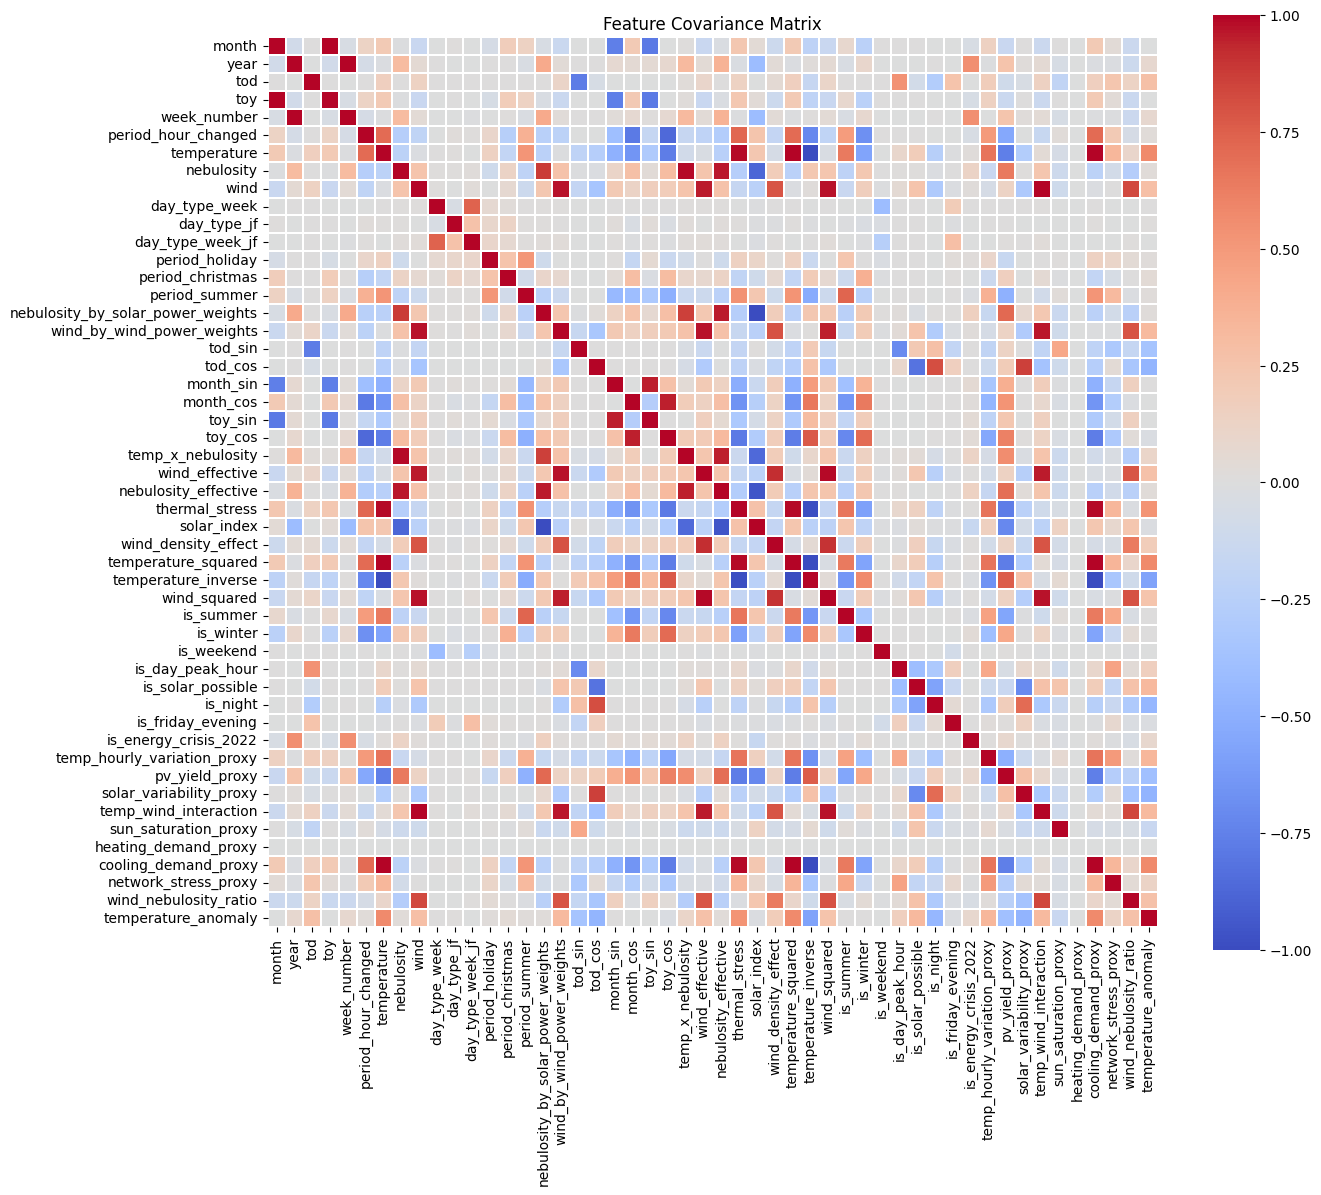

In [129]:
# === Covariance Matrix ===
cov_matrix = X1.cov()
# Figure 1 — Feature covariance matrix (multicollinearity check)
plt.figure(figsize=(14, 12))
sns.heatmap(cov_matrix, cmap="coolwarm", center=0, 
            annot=False, linewidths=0.1, square=True)
plt.title("Feature Covariance Matrix")
plt.tight_layout()
plt.show()

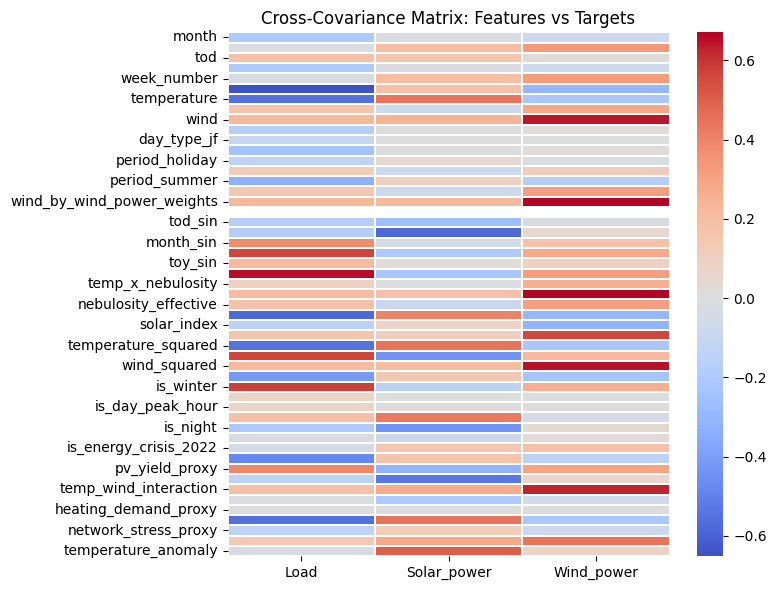

In [128]:
# Crossed Covariance
X_centered = X1 - X1.mean()
Y_centered = Y1 - Y1.mean()
cov_XY = (X_centered.T @ Y_centered) / (len(X) - 1)
cov_XY_df = pd.DataFrame(cov_XY, index=X.columns, columns=Y.columns)

# Figure 2 — Cross-covariance matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cov_XY_df[["Load", "Solar_power", "Wind_power"]],
            cmap="coolwarm", center=0, annot=False, linewidths=0.3)
plt.title("Cross-Covariance Matrix: Features vs Targets")
plt.tight_layout()
plt.show()

In [122]:
# Parameters selection based on crossed covariance
threshold = 0.15  

X_load_vars = cov_XY_df.index[cov_XY_df["Load"].abs() > threshold].tolist()
X_solar_vars = cov_XY_df.index[cov_XY_df["Solar_power"].abs() > threshold].tolist()
X_wind_vars = cov_XY_df.index[cov_XY_df["Wind_power"].abs() > threshold].tolist()

X_train_load=X_train[X_load_vars].copy()
X_train_solar=X_train[X_solar_vars].copy()
X_train_wind=X_train[X_wind_vars].copy()

X_test_load=X_test[X_load_vars].copy()
X_test_solar=X_test[X_solar_vars].copy()
X_test_wind=X_test[X_wind_vars].copy()

## 3. Model Benchmarking

Quick benchmark of three gradient boosting models with default-ish hyperparameters.
The main focus of this project was feature engineering — model selection was secondary.

## 3a. CatBoost Models — One per Target

Three separate CatBoost regressors are trained: one for Load, one for Solar power, one for Wind power.
Hyperparameters were tuned independently for each target.

In [109]:
# === Datasets for CatBoost ===
cat_model_load = CatBoostRegressor(iterations=200, learning_rate=0.07, max_depth=10,loss_function='RMSE', eval_metric='RMSE',random_seed=42, verbose=False, task_type='CPU')
cat_model_solar = CatBoostRegressor(iterations=1200, learning_rate=0.045, max_depth=8,loss_function='RMSE', eval_metric='RMSE',random_seed=42, verbose=False, task_type='CPU')
cat_model_wind = CatBoostRegressor(iterations=150, learning_rate=0.04, max_depth=10,loss_function='RMSE', eval_metric='RMSE',random_seed=42, verbose=False, task_type='CPU')

# === Training ===
cat_model_load.fit(X_train, y_train_load);
cat_model_solar.fit(X_train, y_train_solar);
cat_model_wind.fit(X_train, y_train_wind);

## 3b. XGBoost Models — One per Target

Three separate xgBoost regressors are trained: one for Load, one for Solar power, one for Wind power.
Hyperparameters were tuned independently for each target.

In [110]:
# === Datasets for XGBoost ===
xgb_model_load = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.1 ,max_depth= 6,random_state=42, n_jobs=-1, )
xgb_model_solar = xgb.XGBRegressor(n_estimators=3000, learning_rate=0.1 ,max_depth= 6,random_state=42, n_jobs=-1, )
xgb_model_wind= xgb.XGBRegressor(n_estimators=3000, learning_rate=0.1 ,max_depth= 6,random_state=42, n_jobs=-1, )

# === Training ===
xgb_model_load.fit(X_train, y_train_load);
xgb_model_solar.fit(X_train, y_train_solar);
xgb_model_wind.fit(X_train, y_train_wind);

## 3c. LightGBM Models — One per Target

Three separate LightGBM regressors are trained: one for Load, one for Solar power, one for Wind power.
Hyperparameters were tuned independently for each target.

In [ ]:
# === Datasets for LightGBM ===
lgb_model_load = lgb.LGBMRegressor(boosting_type='gbdt',learning_rate=0.05,n_estimators=1000,max_depth=6,random_state=42,n_jobs=-1,verbose=-1)
lgb_model_solar = lgb.LGBMRegressor(boosting_type='gbdt',learning_rate=0.05,n_estimators=1000,max_depth=6,random_state=42,n_jobs=-1,verbose=-1)
lgb_model_wind = lgb.LGBMRegressor(boosting_type='gbdt',learning_rate=0.05,n_estimators=1000,max_depth=6,random_state=42,n_jobs=-1,verbose=-1)

# === Training ===
lgb_model_load.fit(X_train, y_train_load);
lgb_model_solar.fit(X_train, y_train_solar);
lgb_model_wind.fit(X_train, y_train_wind);

## 4. Evaluation & Final Prediction

The electricity balance is computed as: `Balance = Load - Solar - Wind`

In [ ]:
# === Predictions ===

# CatBoost
y_pred_cat_load = cat_model_load.predict(X_test)
y_pred_cat_solar = cat_model_solar.predict(X_test)
y_pred_cat_wind = cat_model_wind.predict(X_test)
y_pred_cat_balance = y_pred_cat_load - y_pred_cat_solar - y_pred_cat_wind

# XGBoost
y_pred_xgb_load = xgb_model_load.predict(X_test)
y_pred_xgb_solar = xgb_model_solar.predict(X_test)
y_pred_xgb_wind = xgb_model_wind.predict(X_test)
y_pred_xgb_balance = y_pred_xgb_load - y_pred_xgb_solar - y_pred_xgb_wind

# LightGBM
y_pred_lgb_load = lgb_model_load.predict(X_test)
y_pred_lgb_solar = lgb_model_solar.predict(X_test)
y_pred_lgb_wind = lgb_model_wind.predict(X_test)
y_pred_lgb_balance = y_pred_lgb_load - y_pred_lgb_solar - y_pred_lgb_wind

# === Results Table ===
y_test_load = Y_test["Load"]
y_test_solar = Y_test["Solar_power"]
y_test_wind = Y_test["Wind_power"]
y_test_balance = Y_test["Electricity_balance_not_controllable"]

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

results = pd.DataFrame({
    'RMSE Load':    [rmse(y_test_load, y_pred_cat_load),    rmse(y_test_load, y_pred_xgb_load),    rmse(y_test_load, y_pred_lgb_load)],
    'RMSE Solar':   [rmse(y_test_solar, y_pred_cat_solar),  rmse(y_test_solar, y_pred_xgb_solar),  rmse(y_test_solar, y_pred_lgb_solar)],
    'RMSE Wind':    [rmse(y_test_wind, y_pred_cat_wind),    rmse(y_test_wind, y_pred_xgb_wind),    rmse(y_test_wind, y_pred_lgb_wind)],
    'RMSE Balance': [rmse(y_test_balance, y_pred_cat_balance), rmse(y_test_balance, y_pred_xgb_balance), rmse(y_test_balance, y_pred_lgb_balance)]
}, index=['CatBoost', 'XGBoost', 'LightGBM'])

results.round(1)

,RMSE Load,RMSE Solar,RMSE Wind,RMSE Balance
CatBoost,2233.0,854.5,1405.7,3008.8
XGBoost,2328.2,928.6,1582.8,3088.0
LightGBM,2027.3,859.9,1526.4,2761.5


## 5. Test Set Prediction & Kaggle Submission

CatBoost was selected for the final submission as it achieved the lowest RMSE across all three targets.

In [ ]:
df_test2 = pd.read_csv("test.csv")
df_test = build_features(df_test2)
df_test = df_test.drop(columns=["datetime", "date", "Date", "Id"], errors="ignore")

# === Test Set Prediction & Kaggle Submission ===
y_pred_cat_load = cat_model_load.predict(df_test)
y_pred_cat_solar = cat_model_solar.predict(df_test)
y_pred_cat_wind = cat_model_wind.predict(df_test)
y_pred = y_pred_cat_load - y_pred_cat_solar - y_pred_cat_wind

output_df = pd.DataFrame({
    'Id': df_test2['Id'].values,
    'predicted': y_pred
})
output_df.to_csv("predictions.csv", index=False)